# DoRA 交互教学（专题压轴）

配套 lecture：[`../lectures/08-dora.md`](../lectures/08-dora.md)  
配套论文：[`../papers/08-dora-2024.pdf`](../papers/08-dora-2024.pdf)

本 notebook 演示：
1. 权重分解 W = m · V / ||V||_c
2. 初始 W_DoRA = W_0 强一致性
3. peft 调包对照
4. DoRA vs LoRA vs PiSSA 三方 mini training
5. 全 12 方法横向对比汇总

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

src_dir = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src_dir))

from dora_minimal import DoRAGPT2, DoRALinear, _extract_weight_out_in
from lora_minimal import LoRAGPT2
from pissa_minimal import PiSSAGPT2
from common import print_param_summary

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. DoRA 权重分解结构

In [2]:
torch.manual_seed(42)
dora = DoRAGPT2(r=8, alpha=16)
print_param_summary(dora, 'DoRA (r=8)')

layer0 = dora.lm.transformer.h[0].attn.c_attn
print(f'\nlayer 0:')
print(f'  m  shape: {tuple(layer0.m.shape)} = (d_in=768,)')
print(f'  A  shape: {tuple(layer0.A.shape)}')
print(f'  B  shape: {tuple(layer0.B.shape)}')
print(f'  m[:4]: {layer0.m[:4].tolist()}')
print(f'  → m 初始 = ||W_0||_c 的对应列范数')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16942.98it/s]

  DoRA (r=8)
  Total params:      124,743,936
  Trainable params:      304,128  (0.2438%)
  Frozen params:     124,439,808

layer 0:
  m  shape: (768,) = (d_in=768,)
  A  shape: (8, 768)
  B  shape: (2304, 8)
  m[:4]: [9.341294288635254, 9.212672233581543, 8.7094087600708, 9.434226036071777]
  → m 初始 = ||W_0||_c 的对应列范数


## 2. 强一致性：初始 W_DoRA = W_0

In [3]:
from transformers import GPT2LMHeadModel
base = GPT2LMHeadModel.from_pretrained('gpt2')

max_diff = 0.0
for i in range(12):
    layer = dora.lm.transformer.h[i].attn.c_attn
    W_dora = layer._compute_W_dora()
    W_0 = _extract_weight_out_in(base.transformer.h[i].attn.c_attn)
    diff = (W_dora - W_0).abs().max().item()
    max_diff = max(max_diff, diff)
print(f'12 层 max(|W_DoRA - W_0|) = {max_diff:.4e}')
print('→ 初始时模型行为与原始 GPT-2 完全等价（公式 1 验证）')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16463.08it/s]

12 层 max(|W_DoRA - W_0|) = 0.0000e+00
→ 初始时模型行为与原始 GPT-2 完全等价（公式 1 验证）


## 3. peft DoRA 调包

In [4]:
from dora_peft import build_peft_model

torch.manual_seed(42)
peft_dora = build_peft_model(r=8, alpha=16)
print_param_summary(peft_dora, 'peft DoRA')

print('\npeft 内部 layer 0:')
for name, p in peft_dora.named_parameters():
    if 'h.0.attn.c_attn' in name and ('lora' in name or 'magnitude' in name):
        print(f'  {name}: shape={tuple(p.shape)}')
print('\n注：peft 的 magnitude 是 d_out 维 (2304)，minimal 是 d_in 维 (768)')
print('两者都是合理的 "column-wise" 实现，差别仅在选哪个维度做 normalize')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 18135.41it/s]

W0603 16:22:13.807000 16868 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


  peft DoRA
  Total params:      124,762,368
  Trainable params:      322,560  (0.2585%)
  Frozen params:     124,439,808

peft 内部 layer 0:
  base_model.model.transformer.h.0.attn.c_attn.lora_A.default.weight: shape=(8, 768)
  base_model.model.transformer.h.0.attn.c_attn.lora_B.default.weight: shape=(2304, 8)
  base_model.model.transformer.h.0.attn.c_attn.lora_magnitude_vector.default.weight: shape=(2304,)

注：peft 的 magnitude 是 d_out 维 (2304)，minimal 是 d_in 维 (768)
两者都是合理的 "column-wise" 实现，差别仅在选哪个维度做 normalize


C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\peft\tuners\lora\layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## 4. DoRA vs LoRA vs PiSSA 三方对比

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14195.87it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17032.71it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17174.08it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


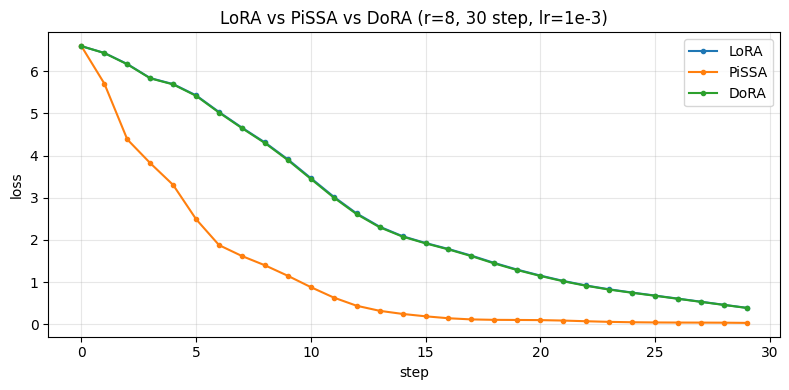

  LoRA final loss: 0.3910
 PiSSA final loss: 0.0335
  DoRA final loss: 0.3875


In [5]:
torch.manual_seed(42)
lora = LoRAGPT2(r=8, alpha=16)
torch.manual_seed(42)
pissa = PiSSAGPT2(r=8, alpha=8)
torch.manual_seed(42)
dora = DoRAGPT2(r=8, alpha=16)

tok = lora.tokenizer
inputs = tok([
    'hello world this is a test',
    'i love this amazing product',
    'absolutely terrible movie',
    'fantastic experience from start to finish'
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

models = [
    ('LoRA',  lora,  torch.optim.AdamW([p for p in lora.parameters() if p.requires_grad], lr=1e-3)),
    ('PiSSA', pissa, torch.optim.AdamW([p for p in pissa.parameters() if p.requires_grad], lr=1e-3)),
    ('DoRA',  dora,  torch.optim.AdamW([p for p in dora.parameters() if p.requires_grad], lr=1e-3)),
]

losses = {name: [] for name, _, _ in models}
for step in range(30):
    for name, m, opt in models:
        opt.zero_grad()
        out = m(**inputs)
        out.loss.backward()
        opt.step()
        losses[name].append(out.loss.item())

plt.figure(figsize=(8, 4))
for name in losses:
    plt.plot(losses[name], label=name, marker='o', markersize=3)
plt.xlabel('step')
plt.ylabel('loss')
plt.title('LoRA vs PiSSA vs DoRA (r=8, 30 step, lr=1e-3)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
for name in losses:
    print(f'{name:>6} final loss: {losses[name][-1]:.4f}')

## 5. 全 12 方法横向对比（汇总）

In [6]:
data = [
    ('LoRA',        2021, '$BA$',                          12 * (8*768 + 2304*8),    'α/r',        '通用'),
    ('rsLoRA',      2023, '$BA$ (α/√r)',                   12 * (8*768 + 2304*8),    'α/√r',       '大 r'),
    ('LoRA+',       2024, '$BA$ (不同 lr)',                 12 * (8*768 + 2304*8),    'α/r',        '加速'),
    ('AdaLoRA',     2023, '$P Λ Q^T$',                     12 * (12*768 + 12 + 2304*12), 'α/r',    '自适应秩'),
    ('PiSSA',       2024, '$BA$ (SVD init)',                12 * (8*768 + 2304*8),    'α/r',        '加速收敛'),
    ('OLoRA',       2024, '$BA$ (QR init)',                 12 * (8*768 + 2304*8),    'α/r',        '正交初始化'),
    ('VeRA',        2024, '$Λ_d ⊙ B Λ_b A$',               12 * (256 + 2304),         'α/r',        '极致压缩'),
    ('LoHa',        2021, '$(B_1A_1)⊙(B_2A_2)$',           12 * 2 * (8*768 + 2304*8), '—',          'r² 秩'),
    ('LoKr',        2023, '$B ⊗ A$',                       23808,                     '—',          'SD'),
    ('QLoRA',       2023, 'NF4($W$) + $BA$',                12 * (8*768 + 2304*8),    'α/r',        '量化'),
    ('LoftQ',       2023, 'NF4($W-BA^*$) + $BA^*$',         12 * (8*768 + 2304*8),    'α/r',        '量化精度'),
    ('DoRA',        2024, '$m·\\frac{W_0+BA}{||W_0+BA||_c}$', 12 * (8*768 + 2304*8 + 768), 'α/r',  '接近 FT'),
]

print(f'{"方法":<10}{"年份":>6}{"参数量":>15}{"scaling":>10}{"主战场":>15}')
print('-' * 65)
for name, year, form, params, scaling, niche in data:
    print(f'{name:<10}{year:>6}{params:>15,}{scaling:>10}{niche:>15}')

方法            年份            参数量   scaling            主战场
-----------------------------------------------------------------
LoRA        2021        294,912       α/r             通用
rsLoRA      2023        294,912      α/√r            大 r
LoRA+       2024        294,912       α/r             加速
AdaLoRA     2023        442,512       α/r           自适应秩
PiSSA       2024        294,912       α/r           加速收敛
OLoRA       2024        294,912       α/r          正交初始化
VeRA        2024         30,720       α/r           极致压缩
LoHa        2021        589,824         —           r² 秩
LoKr        2023         23,808         —             SD
QLoRA       2023        294,912       α/r             量化
LoftQ       2023        294,912       α/r           量化精度
DoRA        2024        304,128       α/r          接近 FT


C:\Users\ericp\AppData\Local\Temp\ipykernel_16868\1654137920.py:12: UserWarning: Glyph 23478 (\N{CJK UNIFIED IDEOGRAPH-5BB6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_16868\1654137920.py:12: UserWarning: Glyph 26063 (\N{CJK UNIFIED IDEOGRAPH-65CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_16868\1654137920.py:12: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_16868\1654137920.py:12: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_16868\1654137920.py:12: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_16868\1654137920.py:12: UserWarning: Glyph 25968 (\

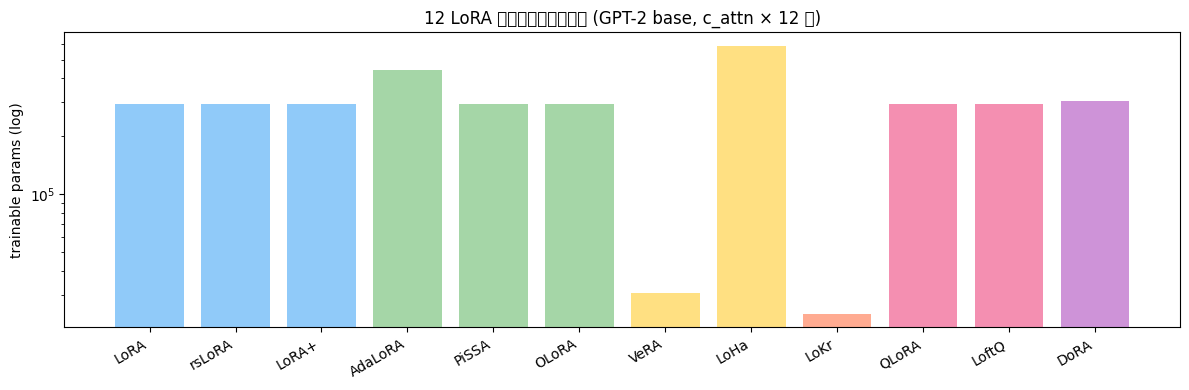

In [7]:
# 参数量横向柱状图
names = [d[0] for d in data]
params = [d[3] for d in data]
colors = ['#90caf9'] * 3 + ['#a5d6a7'] * 3 + ['#ffe082'] * 2 + ['#ffab91'] * 1 + ['#f48fb1'] * 2 + ['#ce93d8'] * 1

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(names, params, color=colors)
ax.set_yscale('log')
ax.set_ylabel('trainable params (log)')
ax.set_title('12 LoRA 家族方法参数量对比 (GPT-2 base, c_attn × 12 层)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 6. 思考题与全专题终点

**主篇思考题**：
1. **公式题**：写出 $W_0 + BA$ 的 column-wise norm 解析公式。如果 $B = 0$，norm 等于什么？
2. **公式题**：推导 ∂L/∂m。detach ||V|| 后，与不 detach 相差多少？
3. **代码题**：在 `dora_minimal.py` 加 `merge_to_base()` 方法（已实现），验证合并后参数量。
4. **设计题**：DoRA 用 column-wise norm，能否改 row-wise？两者各适合什么场景？
5. **对比题**：解释 DoRA 与 BatchNorm/LayerNorm 在 'scale-shift' 思想上的相似性。
6. **实践题**：QDoRA = QLoRA + DoRA，把 `qlora_minimal.py` 与 `dora_minimal.py` 组合实现。

**全专题终点**：

```
你已经走完 LoRA 家族 12 种方法的完整路径：

01 LoRA            基础低秩
02 AdaLoRA         SVD + 重要性
03 PiSSA           SVD 初始化
04 VeRA            共享 + 对角（极致压缩）
05 LoHa+LoKr      Hadamard / Kronecker（结构变换）
06 QLoRA           NF4 量化
07 LoftQ           量化感知初始化
08 DoRA            权重分解（接近 FT）⭐
```

**下一步**：
- 横向对比表（见上）→ 工程选型
- 长上下文专题（LongLoRA / PI / YaRN）
- 对齐专题（RLHF / DPO / SimPO，回到书本主线）